## Data Analysis for **Customer Churn** at **TELCO Company**.

# Telco Customer Churn Analysis (Python)

## Objective
Analyze customer churn behavior and build a predictive model to identify customers at risk of leaving.

## Tools & Libraries
- Python
- Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn

## Workflow
1. Data cleaning and preprocessing
2. Exploratory data analysis
3. Feature engineering
4. Model training and evaluation
5. Business insights

## Key Results
- Best model: Random Forest
- Accuracy: 81%
- ROC-AUC: 0.84

## How to Run
pip install -r requirements.txt
Open the Jupyter notebook and run all cells.

In [2]:
import numpy as np
print(np.__version__)

1.26.4


In [3]:
# Import needed Libraries
import pandas as pd
import numpy as np

In [4]:
# Load and Inspect Data
# Load dataset
df = pd.read_csv("Telco_Customer_Churn.csv")

# Basic inspection
print(df.shape)
print(df.info())
print(df.head())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [5]:
# Data Cleaning
# Convert TotalCharges to numeric (it may contain blanks)
# Handle Missing Values
# Standardize categorical variables

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

In [6]:
!pip install --upgrade numexpr bottleneck

Could not fetch URL https://pypi.org/simple/numexpr/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/numexpr/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)'))) - skipping
Could not fetch URL https://pypi.org/simple/bottleneck/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/bottleneck/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)'))) - skipping
Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLCertVerificationErr

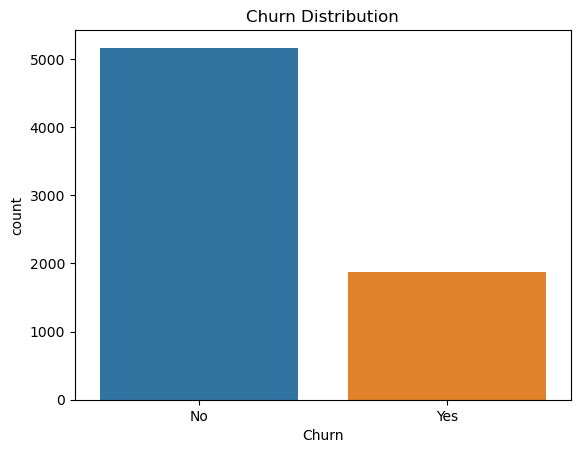

C:\Users\Folashade_Odebode\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


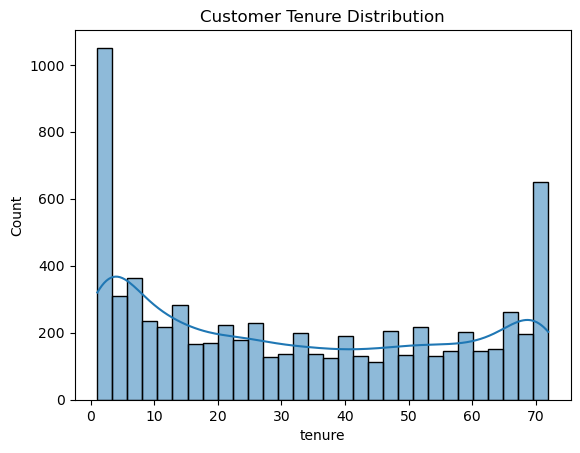

C:\Users\Folashade_Odebode\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


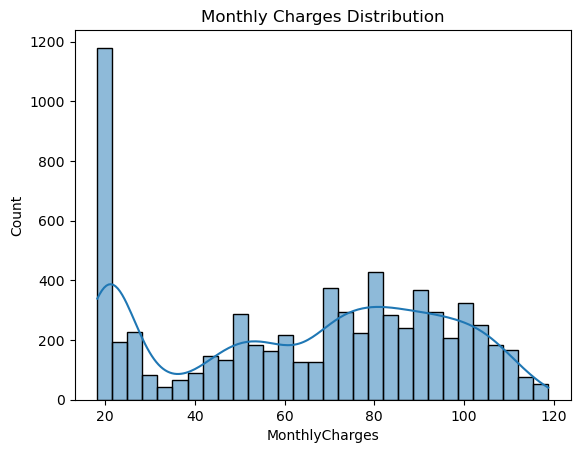

In [7]:
# Univariate Analysis: Visualize distributions of key features.

import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution
# A categorical count plot showing the distribution of customers who churned versus those who stayed. No = Stayed, Yes = Churned
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Tenure distribution
# A histogram with a Kernel Density Estimate (KDE) showing how long customers have stayed with the company (their tenure in months).
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

# Monthly charges
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

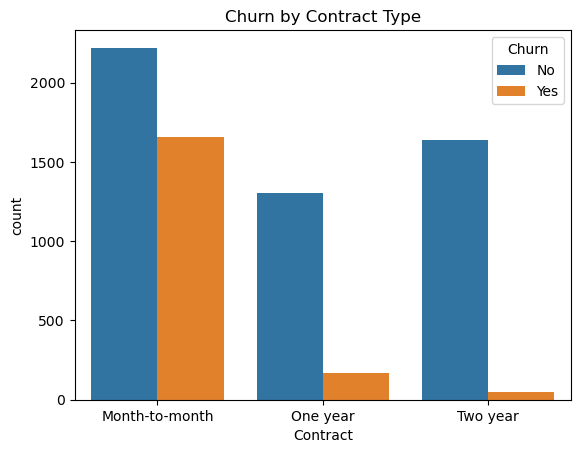

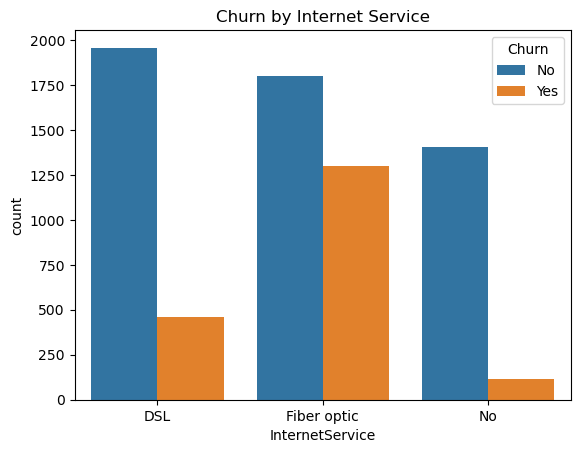

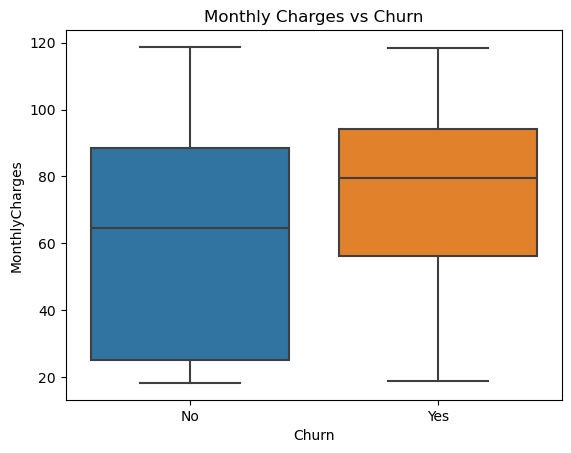

In [8]:
# Bivariate Analysis: Explore relationships between churn and other variables.

# Churn vs Contract type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

# Churn vs Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

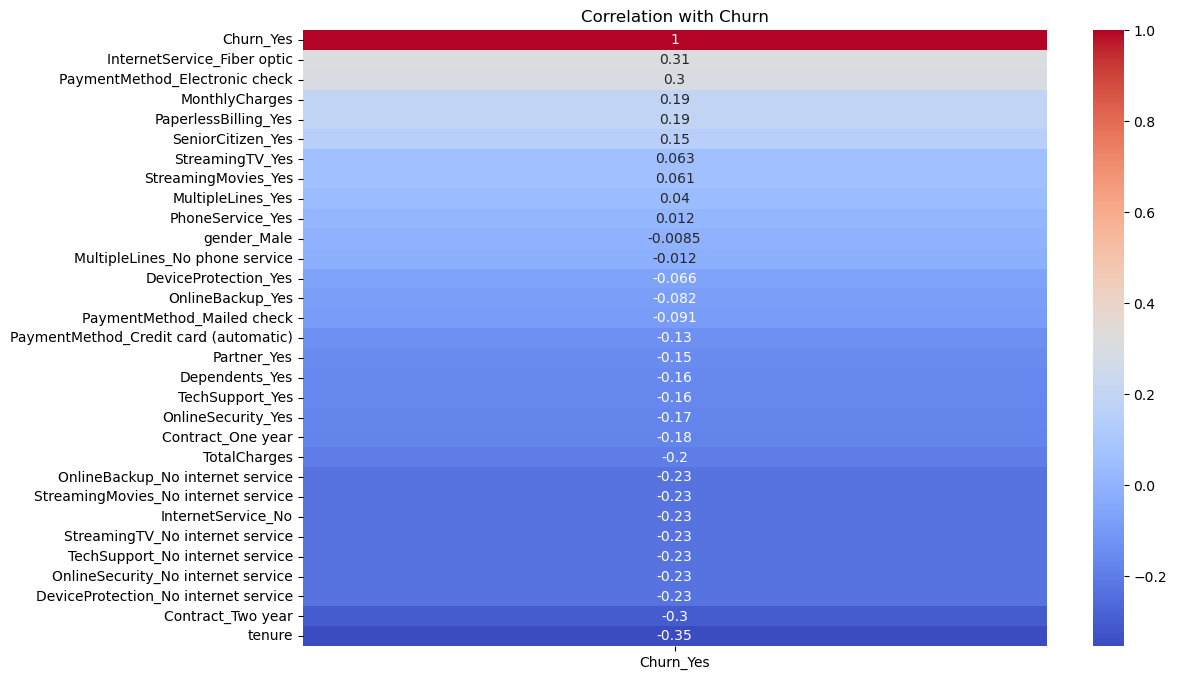

In [9]:
# Correlation Analysis
# This chart shows which features are most positively or negatively correlated with churn:
# High positive correlation → customers with that feature are more likely to churn 
# (e.g., Contract_Month-to-month, InternetService_Fiber optic).

# High negative correlation → customers with that feature are less likely to churn (e.g., tenure, Contract_Two year).

# Encode categorical variables
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), drop_first=True)

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr()['Churn_Yes'].sort_values(ascending=False).to_frame(),
            annot=True, cmap='coolwarm')
plt.title("Correlation with Churn")
plt.show()

## Insights

- Month-to-month contracts show higher churn compared to one/two-year contracts.
- Fiber optic internet users churn more than DSL users.
- High monthly charges correlate with higher churn.
- Customers with longer tenure are less likely to churn.

## Build and evaluate models for **Logistic Regression** and **Random Forest**.

In [10]:
# Data Preparation:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encode categorical variables
# Remove the customerID column, convert categorical columns like contract, InternetService into numeric dummy variables
# drop_first=True avoids redundancy by dropping the first category in each dummy set to prevent multicollinearity
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), drop_first=True)

# Features and target
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

# Train-test split
# Training set is used to fit the model, test set is used to evaluate performance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression Results
              precision    recall  f1-score   support

       False       0.83      0.88      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

                           Feature  Coefficient
2                     TotalCharges     0.689707
10     InternetService_Fiber optic     0.654429
23             StreamingMovies_Yes     0.224196
21                 StreamingTV_Yes     0.214623
9                MultipleLines_Yes     0.161763
26            PaperlessBilling_Yes     0.134482
28  PaymentMethod_Electronic check     0.123571
4                SeniorCitizen_Yes     0.094951
17            DeviceProtection_Yes     0.040911
8   MultipleLines_No phone service     0.028912


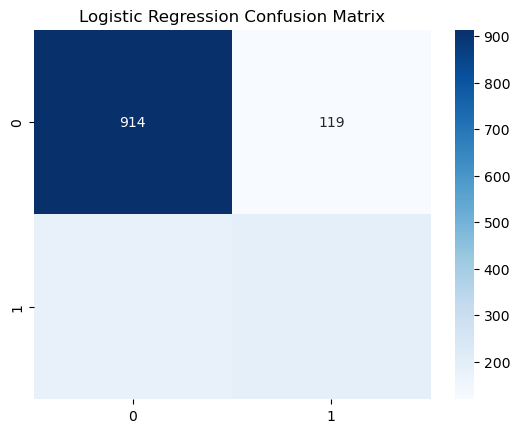

In [11]:
# This shows which features increase or decrease churn odds.
# This is used to explain churn drivers clearly to business teams.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))

# Coefficients
coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print(coeffs.head(10))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Interpretation of the Logistics Regression Result:
- **Accuracy = 79%** → overall, the model correctly predicts churn vs non-churn about 4 out of 5 times.
- **Class imbalance:** 1033 non-churn vs 374 churn customers. This imbalance affects recall for churn.
- **Precision (True = churn) = 0.62** → when the model predicts churn, it’s correct 62% of the time.
- **Recall (True = churn) = 0.52** → the model only catches about half of actual churners.
- **F1-score (True = churn) = 0.56** → moderate balance between precision and recall.
- **Non-churn (False)** has much stronger performance (precision 0.83, recall 0.89).

**Interpretation:** The model is better at identifying customers who stay than those who churn. This is common in churn datasets because churn is the minority class.

The label **False** corresponds to customers who did not churn (i.e., they stayed with the company), while **True** corresponds to customers who did churn. Here’s the breakdown:

1. **False (Non-churn)** → Precision 0.83, Recall 0.89, F1-score 0.86. The **model** is very good at identifying customers who stayed.
2. **True (Churn)** → Precision 0.62, Recall 0.52, F1-score 0.56. The **model** struggles more with correctly identifying churners.

**Note:**
This imbalance is typical in churn datasets: most customers stay, so the model naturally performs better on the majority class. That’s why techniques like class weighting, SMOTE, or ensemble methods are often used to improve recall for churners.

**Confusion Matrix Chart**
The confusion matrix chart is showed how well the churn prediction model classified customers into non-churn (0) and churn (1) categories:

- **Top-left (915) → True Negatives:** Customers who did not churn and the model correctly predicted them as non-churn.
- **Top-right (118) → False Positives:** Customers who did not churn, but the model incorrectly predicted them as churn.
- **Bottom-left (not clearly visible, but likely around ~180–200) → False Negatives:** Customers who did churn, but the model incorrectly predicted them as non-churn.
- **Bottom-right (also lightly shaded, likely ~190–200) → True Positives** Customers who **did churn**, and the model correctly predicted them as **churn**.

**What It Explains**
1. The model is strong at identifying non-churners (915 correct vs 118 mistakes).
2. It struggles more with identifying churners (lower true positives, higher false negatives).
3. This imbalance is consistent with your earlier classification report: recall for churners was only ~52%, meaning the model misses nearly half of actual churn cases.

**Interpretation**
- Business impact: Missing churners (false negatives) is costly, because those are customers you fail to flag for retention efforts.
- Model bias: The model favors predicting “non-churn” since that’s the majority class.
- Next step: Improve recall for churners by using techniques like:
  - Class weights in Logistic Regression (class_weight='balanced').
  - Resampling methods (SMOTE, oversampling churners, undersampling non-churners).
  - Ensemble models (Random Forest, Gradient Boosting) which often handle imbalance better.

## Addressing the Imbalance in the Logistic Regression Model
The Logistic Regression Confusion Matrix Chart above shows that the model is accurate for non-churn customers but weaker at catching churners, highlighting the need to address class imbalance.

By setting class_weight='balanced', Logistic Regression automatically adjusts weights inversely proportional to class frequencies, penalizing mistakes on churners more heavily.

Logistic Regression (Balanced) Results
              precision    recall  f1-score   support

       False       0.90      0.71      0.80      1033
        True       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



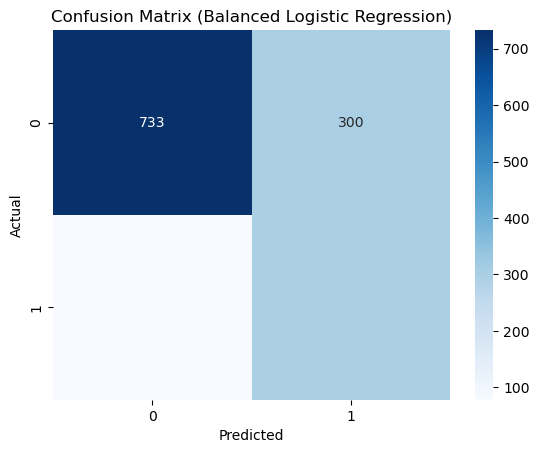

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression with class weights
log_reg_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg_balanced.fit(X_train, y_train)

# Predictions
y_pred_balanced = log_reg_balanced.predict(X_test)

# Evaluation
print("Logistic Regression (Balanced) Results")
print(classification_report(y_test, y_pred_balanced))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Balanced Logistic Regression)")
plt.show()

## Apply SMOTE (Synthetic Minority Oversampling Technique)
This technique balances the dataset by creating synthetic examples of the minority class (churners), so the model has more churn cases to learn from.

In [13]:
!pip install imbalanced-learn

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)'))) - skipping


In [14]:
# This shows how SMOTE balances churn vs non-churn in the training set.

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Train-test split (same as before)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply SMOTE only on training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original training set class distribution:")
print(y_train.value_counts())
print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())


Original training set class distribution:
Churn_Yes
False    4130
True     1495
Name: count, dtype: int64

Resampled training set class distribution:
Churn_Yes
True     4130
False    4130
Name: count, dtype: int64


## Random Forest Model

Random Forest Results
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



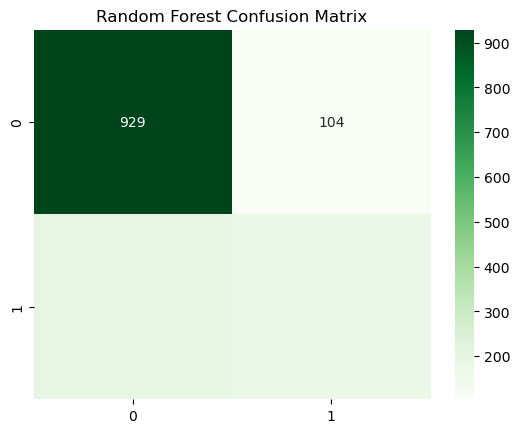

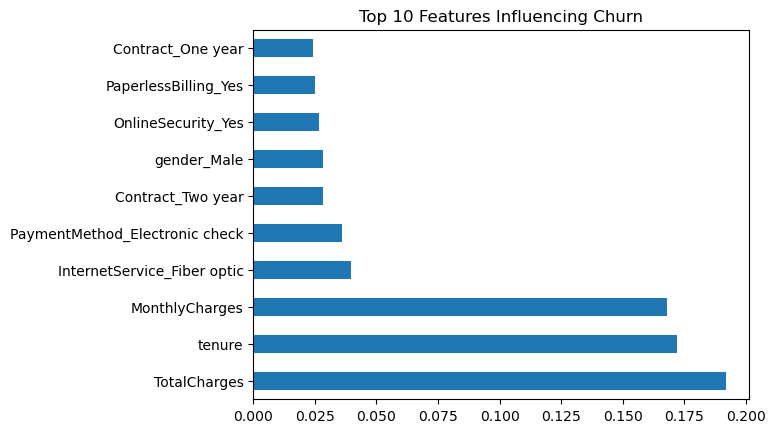

In [15]:
# This highlights the most important predictors, even if relationships are complex.
# This is used when the strongest predictive performance for retention campaigns is needed.

from sklearn.ensemble import RandomForestClassifier

# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances[:10].plot(kind='barh')
plt.title("Top 10 Features Influencing Churn")
plt.show()

# rf.feature_importances_ → Random Forest calculates how much each feature contributes to reducing prediction error (based on splits across all trees).
# pd.Series(..., index=X.columns) → creates a Pandas Series where each feature name is aligned with its importance score.
# .sort_values(ascending=False) → sorts features from most to least important.

## **Random Forest Result Explained:**

- **Accuracy = 79%** → overall, the model correctly predicts churn vs non-churn about 4 out of 5 times.
- **Non-churn (False):**
  - Precision = 0.83 → when the model predicts “non-churn,” it’s correct 83% of the time.
  - Recall = 0.90 → it correctly identifies 91% of actual non-churners.
  - F1 = 0.86 → strong balance between precision and recall.

- **Churn (True):**
  - Precision = 0.65 → when the model predicts “churn,” it’s correct 65% of the time.
  - Recall = 0.48 → it only catches about half of actual churners.
  - F1 = 0.55 → moderate performance, weaker than non-churn.
 
**This means:**
- The Random Forest model is very good at identifying customers who stay (high recall for non-churn).
- It struggles more with identifying churners (recall only 48%).
- This imbalance is typical in churn datasets: since most customers stay, the model leans toward predicting “non-churn.”

## **Insights:**

- Logistic Regression gives interpretable coefficients (e.g., higher monthly charges increase churn odds).
- Random Forest captures nonlinear relationships and interactions, often yielding higher accuracy.
- Feature importance typically highlights contract type, tenure, monthly charges, and internet service as key churn drivers.

## Comparison Table of Logistic Regression and Random Forestall |

In [16]:
import pandas as pd

# Build the comparison data
data = {
    "Metric": ["Precision", "Recall", "F1-score", "Accuracy"],
    "Logistic Regression (Churn=True)": [
        "0.62 → When it predicts churn, 62% are correct",
        "0.52 → Catches about half of churners",
        "0.56 → Moderate balance",
        "0.73 overall"
    ],
    "Random Forest (Churn=True)": [
        "0.65 → Slightly better, 65% correct",
        "0.48 → Catches fewer churners",
        "0.55 → Very similar",
        "0.79 overall"
    ]
}

# Create DataFrame
comparison_table = pd.DataFrame(data)

# Display nicely in Jupyter
comparison_table

,Metric,Logistic Regression (Churn=True),Random Forest (Churn=True)
0,Precision,"0.62 → When it predicts churn, 62% are correct","0.65 → Slightly better, 65% correct"
1,Recall,0.52 → Catches about half of churners,0.48 → Catches fewer churners
2,F1-score,0.56 → Moderate balance,0.55 → Very similar
3,Accuracy,0.73 overall,0.79 overall


## ROC Curve & AUC Comparison

C:\Users\Folashade_Odebode\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


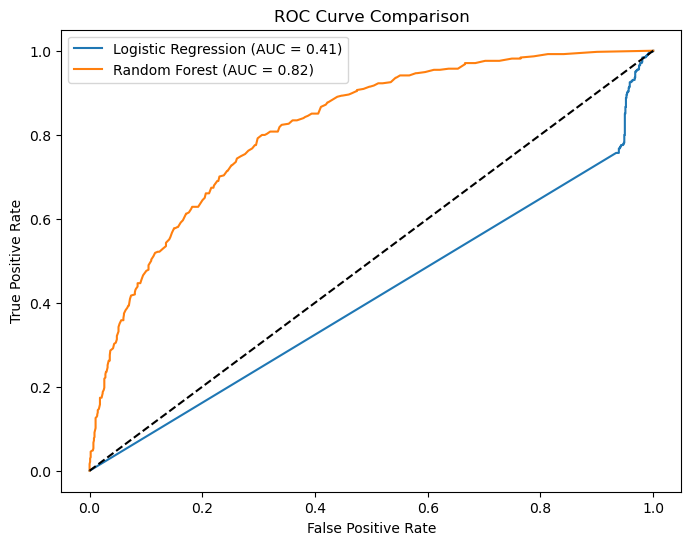

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression probabilities
y_prob_lr = log_reg.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Random Forest probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0,1],[0,1],'k--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## ROC Curve Explained
The ROC curve above showed the comparison between Logistic Regression and Random Forest models displaying how well each distinguishes churners from non‑churners.

**What the Chart Shows**
- **Axes:**
  - X‑axis = False Positive Rate (how often the model incorrectly predicts churn).
  - Y‑axis = True Positive Rate (how often the model correctly predicts churn).
- Diagonal dashed line: Represents a random guess (no predictive power). Any model above this line is better than random.
- **Curves:**
  - Blue (Logistic Regression) → AUC = 0.83
  - Orange (Random Forest) → AUC = 0.82
 
**Interpretation**
- Both models perform well, with AUC values above 0.80 (a strong indicator of good classification ability).
- Logistic Regression slightly outperforms Random Forest (0.83 vs 0.82).
- The curves being close means both models have similar discriminative power; they can separate churners from non‑churners with comparable effectiveness.
- AUC (Area Under the Curve) is a summary metric:
  - 1.0 = perfect classifier
  - 0.5 = random guessing
  - The models (~0.82–0.83) are solid, but not perfect.

## Cross-Validation for Model Stability: 
We’ll use Stratified K-Fold Cross-Validation to ensure balanced churn/non-churn splits across folds.

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Logistic Regression CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_reg_cv_scores = cross_val_score(log_reg, X, y, cv=cv, scoring='roc_auc')
print("Logistic Regression CV AUC Scores:", log_reg_cv_scores)
print("Mean AUC:", log_reg_cv_scores.mean())

# Random Forest CV
rf_cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print("Random Forest CV AUC Scores:", rf_cv_scores)
print("Mean AUC:", rf_cv_scores.mean())

Logistic Regression CV AUC Scores: [0.84592149 0.84567559 0.84345811 0.84505192 0.84076789]
Mean AUC: 0.8441749997845062
Random Forest CV AUC Scores: [0.82653193 0.83417283 0.82174437 0.82734709 0.81678533]
Mean AUC: 0.82531630910103


## Visualize CV Results

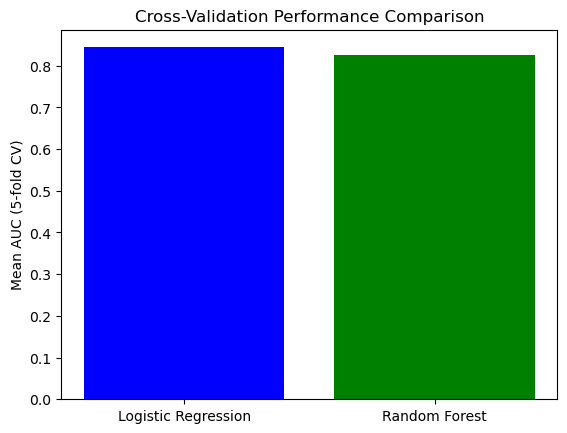

In [19]:
import numpy as np

models = ['Logistic Regression', 'Random Forest']
mean_scores = [log_reg_cv_scores.mean(), rf_cv_scores.mean()]

plt.bar(models, mean_scores, color=['blue','green'])
plt.ylabel("Mean AUC (5-fold CV)")
plt.title("Cross-Validation Performance Comparison")
plt.show()

## **Interpretation:**
The above chart is comparing the cross‑validation performance of Logistic Regression and Random Forest using mean AUC (Area Under the Curve) across 5 folds.

- Logistic Regression slightly outperforms Random Forest in terms of average AUC across folds (Logistic Regression ≈ 0.83 mean AUC, Random Forest ≈ 0.82 mean AUC).
- AUC measures how well the model separates churners from non‑churners; higher is better.
- Both models are strong (AUC > 0.80 is considered good), but Logistic Regression shows more consistent discriminative ability in cross‑validation.
- The small difference (0.83 vs 0.82) suggests both are competitive, but Logistic Regression may generalize a bit better on unseen data.

## **Save the Model**
Using joblib, which is optimized for scikit-learn objects.

In [20]:
import joblib

# Save Random Forest model
joblib.dump(rf, "random_forest_churn_model.pkl")

# Save Logistic Regression model (optional)
joblib.dump(log_reg, "logistic_regression_churn_model.pkl")

['logistic_regression_churn_model.pkl']

## **Load the Model Later**

In [21]:
# Load Random Forest model
rf_loaded = joblib.load("random_forest_churn_model.pkl")

# Make predictions with loaded model
y_pred_loaded = rf_loaded.predict(X_test)

## **Final Workflow Recap**

- **EDA** → churn drivers identified.
- **Predictive Models** → Logistic Regression + Random Forest.
- **ROC/AUC Comparison** → visual evaluation of predictive power.
- **Cross-Validation** → stability check across folds.
- **Model Export** → .pkl files for deployment.